# afeez EDA report

- **Data**: `data/nhanes.csv`
- **Outcome**: `Diabetes`
- **Variables**: Age, Gender, Race1, Weight, Height, Diabetes, BPSysAve, BPDiaAve
- **Filter**: `Age >= 18 & Age <= 50`

Generated by the `afeez` skill.

## 1. Libraries

In [15]:
library(tidyverse)
library(gtsummary)
library(gt)
library(skimr)

## 2. Load and prepare data

In [16]:
data_path   <- "data/nhanes.csv"
outcome     <- "Diabetes"
sel_vars    <- c("Age", "Gender", "Race1", "Weight", "Height", "Diabetes", "BPSysAve", "BPDiaAve")
plots_dir   <- "plots"
table_path  <- "bivariate_table.html"

df <- readr::read_csv(data_path, na = c("", "NA", "N/A", "."))

if (!is.null(sel_vars)) df <- df %>% select(all_of(sel_vars))

# User-supplied filter (or no-op)
df <- df %>% filter(Age >= 18 & Age <= 50)

# Drop rows where outcome is missing; coerce outcome to factor
df <- df %>% filter(!is.na(.data[[outcome]]))
df[[outcome]] <- factor(df[[outcome]])

# Coerce character columns to factor
chr_cols <- names(df)[sapply(df, is.character)]
for (v in chr_cols) df[[v]] <- factor(df[[v]])

dir.create(plots_dir, recursive = TRUE, showWarnings = FALSE)

cat("Rows:", nrow(df), "  Cols:", ncol(df), "\n")
cat("Outcome levels:\n"); print(table(df[[outcome]]))

Rows: 20293 Columns: 78
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Lengt...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 6872   Cols: 8 
Outcome levels:

  No  Yes 
6532  340 


## 3. Dataset overview

In [17]:
glimpse(df)

Rows: 6,872
Columns: 8
$ Age      <dbl> 34, 26, 49, 35, 42, 45, 28, 19, 44, 49, 26, 32, 44, 18, 50, 2…
$ Gender   <fct> male, male, female, female, female, female, male, female, mal…
$ Race1    <fct> White, Mexican, White, White, Black, White, Mexican, Black, W…
$ Weight   <dbl> 87.4, 97.6, 86.7, NA, 107.7, 75.7, 79.4, 111.6, 102.4, 76.5, …
$ Height   <dbl> 164.7, 173.0, 168.4, NA, 164.3, 166.7, 163.4, 165.7, 187.6, 1…
$ Diabetes <fct> No, No, No, No, Yes, No, No, No, No, No, No, No, No, No, No, …
$ BPSysAve <dbl> 113, 104, 112, NA, 116, 118, 100, 93, 119, 138, 126, 111, 129…
$ BPDiaAve <dbl> 85, 49, 75, NA, 100, 64, 68, 70, 85, 78, 80, 76, 88, 72, 68, …


In [18]:
df %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "n_missing") %>%
  mutate(pct_missing = round(100 * n_missing / nrow(df), 1)) %>%
  arrange(desc(n_missing))

# A tibble: 8 × 3
  variable n_missing pct_missing
  <chr>        <int>       <dbl>
1 BPSysAve       539         7.8
2 BPDiaAve       539         7.8
3 Weight         260         3.8
4 Height         257         3.7
5 Age              0         0  
6 Gender           0         0  
7 Race1            0         0  
8 Diabetes         0         0  

In [19]:
skim(df)

── Data Summary ────────────────────────
                           Values
Name                       df    
Number of rows             6872  
Number of columns          8     
_______________________          
Column type frequency:           
  factor                   3     
  numeric                  5     
________________________         
Group variables            None  

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable n_missing complete_rate ordered n_unique
1 Gender                0             1 FALSE          2
2 Race1                 0             1 FALSE          5
3 Diabetes              0             1 FALSE          2
  top_counts                               
1 fem: 3532, mal: 3340                     
2 Whi: 2660, Bla: 1465, Mex: 1141, Oth: 880
3 No: 6532, Yes: 340                       

── Variable type: numeric ──────────────────────────────────────────────────────
  skim_variable n_missing complete_rate  mean    sd

## 4. Normality (Shapiro–Wilk) for numeric predictors

In [20]:
num_vars <- setdiff(names(df)[sapply(df, is.numeric)], outcome)
cat_vars <- setdiff(names(df)[sapply(df, function(x) is.factor(x) || is.character(x))], outcome)

is_normal <- function(x) {
  vals <- na.omit(x)
  n <- length(vals)
  if (n >= 3 && n <= 5000) stats::shapiro.test(vals)$p.value > 0.05 else FALSE
}
normality <- tibble::tibble(
  variable = num_vars,
  is_normal = vapply(num_vars, function(v) is_normal(df[[v]]), logical(1))
)
normality

# A tibble: 5 × 2
  variable is_normal
  <chr>    <lgl>    
1 Age      FALSE    
2 Weight   FALSE    
3 Height   FALSE    
4 BPSysAve FALSE    
5 BPDiaAve FALSE    

## 5. Univariate plots

Numeric: histogram + boxplot. Categorical: bar chart with count and percent labels.
All plots use `theme_minimal()` and are saved to `plots_dir`.

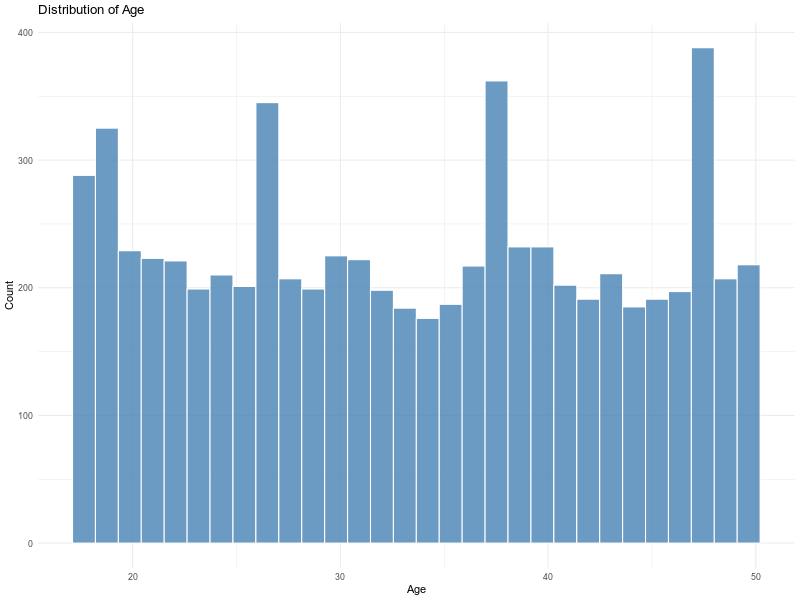

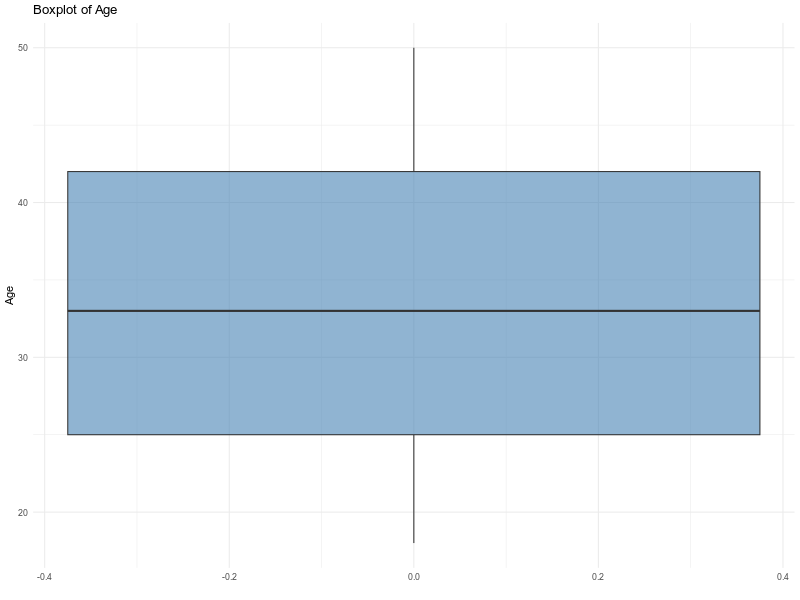

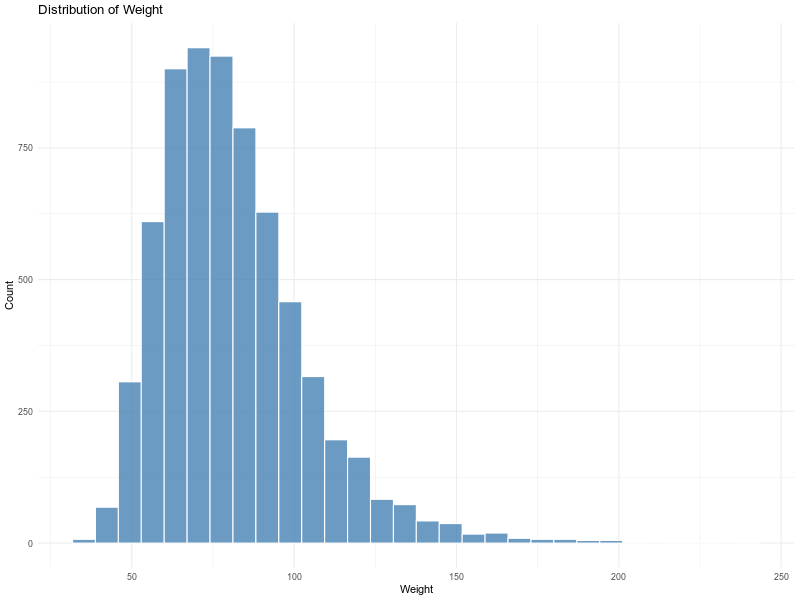

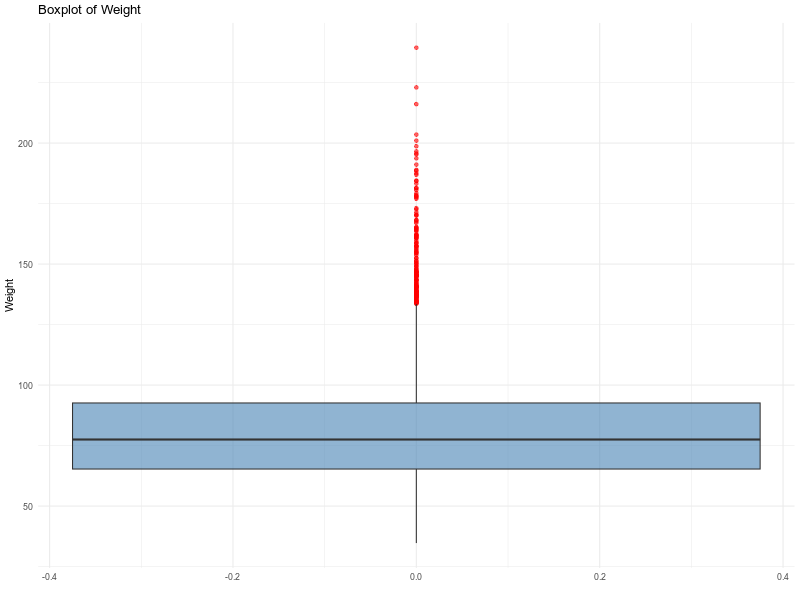

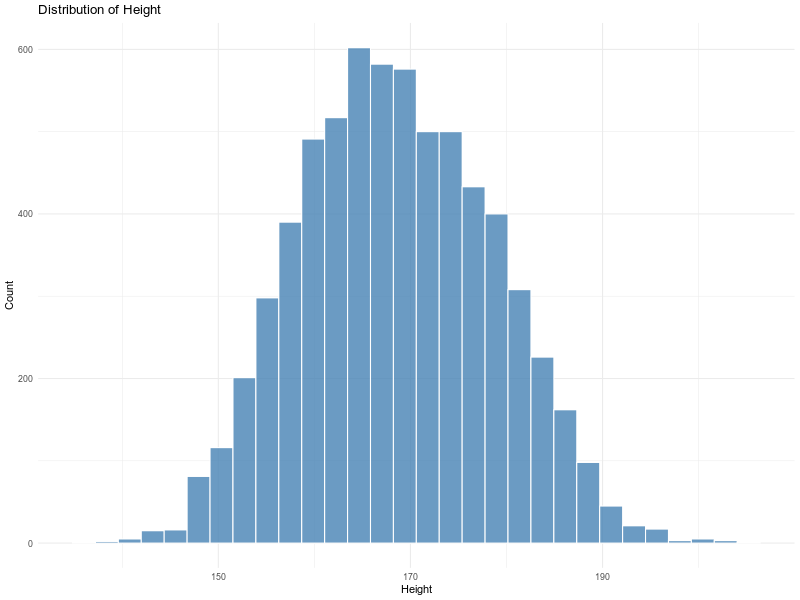

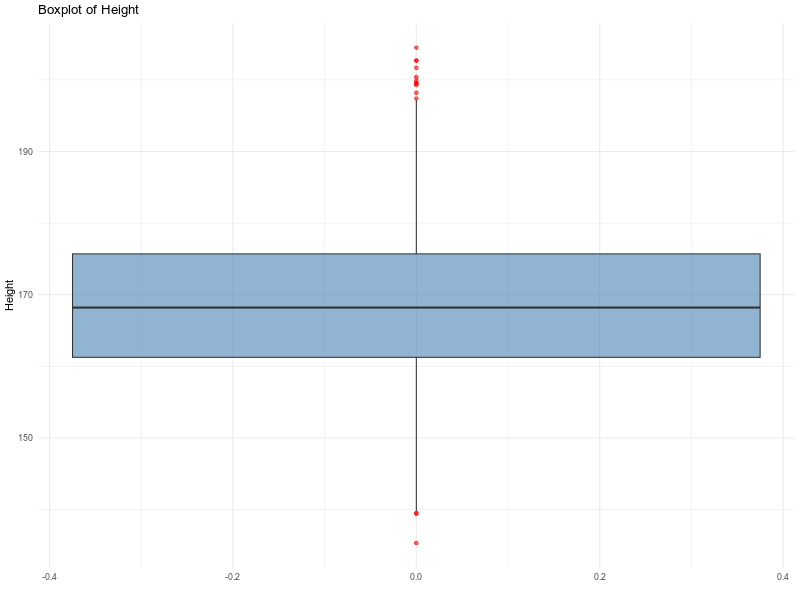

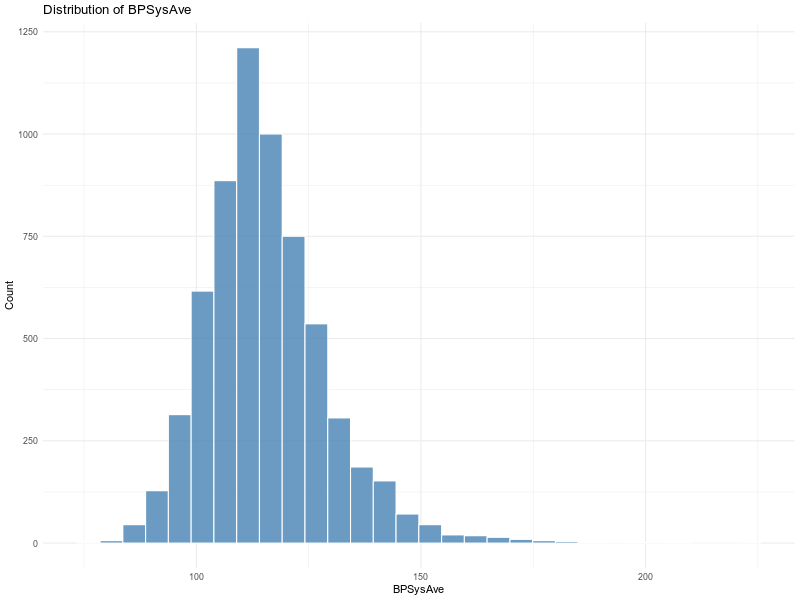

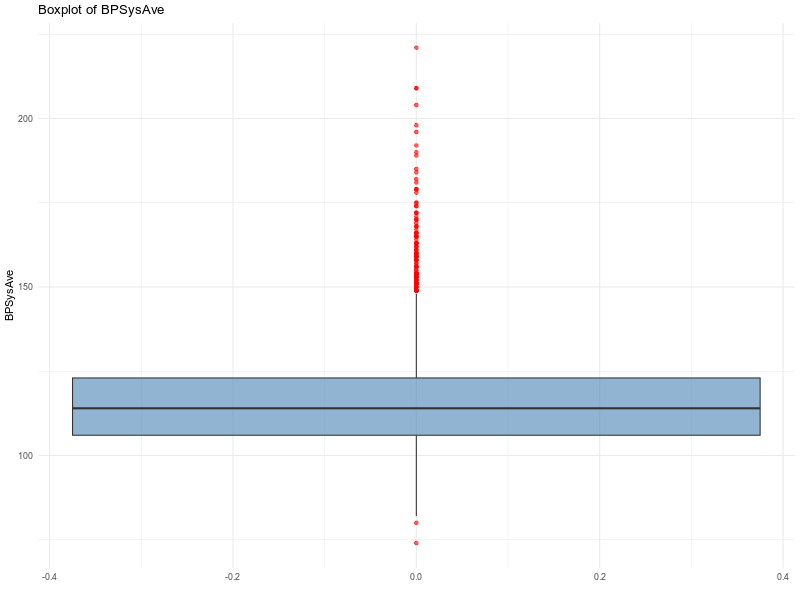

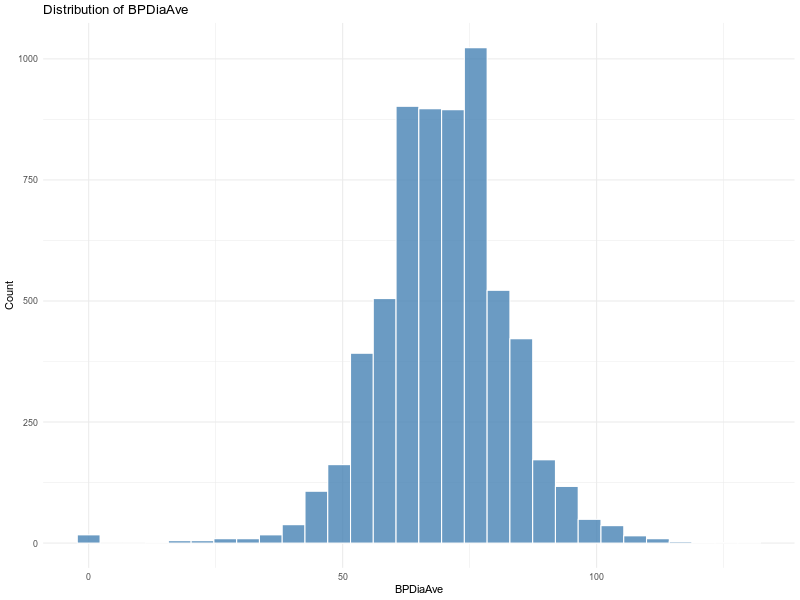

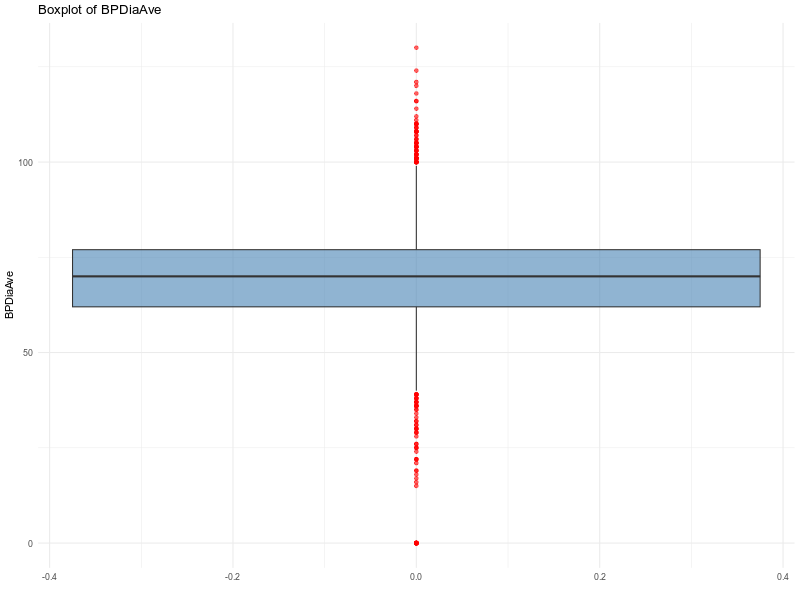

There were 16 warnings (use warnings() to see them)


In [21]:
for (v in num_vars) {
  p_hist <- ggplot(df, aes(x = .data[[v]])) +
    geom_histogram(bins = 30, fill = "steelblue", color = "white", alpha = 0.8) +
    theme_minimal() +
    labs(title = paste("Distribution of", v), x = v, y = "Count")
  print(p_hist)
  ggsave(file.path(plots_dir, paste0("uni_hist_", v, ".png")), p_hist,
         width = 6, height = 4, dpi = 150)

  p_box <- ggplot(df, aes(y = .data[[v]])) +
    geom_boxplot(fill = "steelblue", alpha = 0.6, outlier.color = "red") +
    theme_minimal() +
    labs(title = paste("Boxplot of", v), x = "", y = v)
  print(p_box)
  ggsave(file.path(plots_dir, paste0("uni_box_", v, ".png")), p_box,
         width = 6, height = 4, dpi = 150)
}

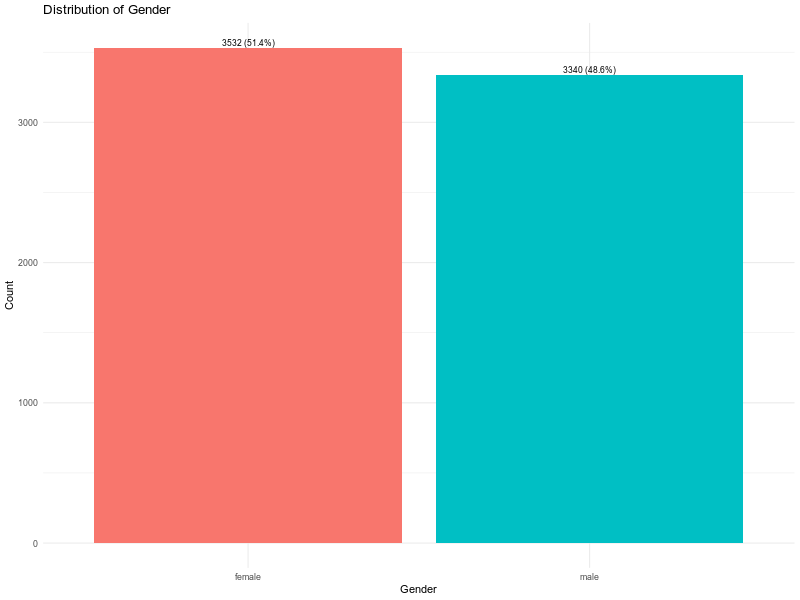

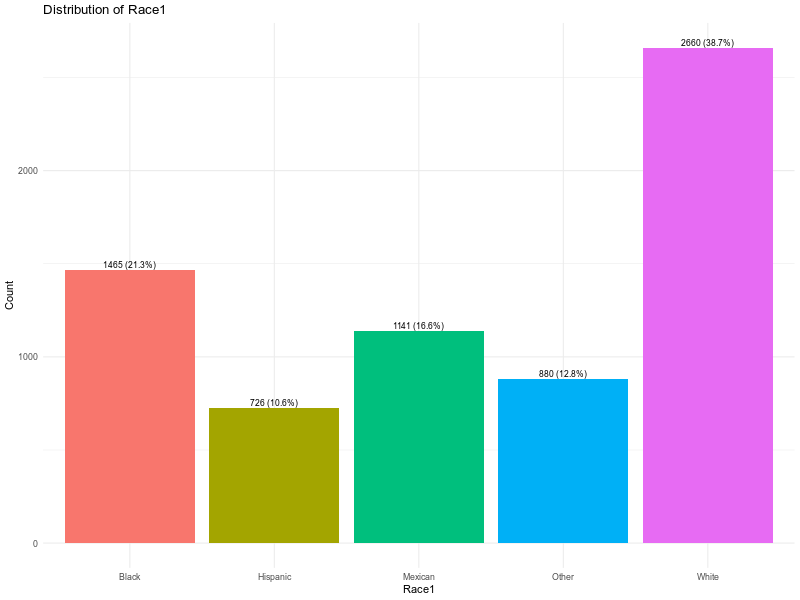

In [22]:
for (v in cat_vars) {
  p_bar <- df %>%
    count(.data[[v]]) %>%
    mutate(pct = scales::percent(n / sum(n), accuracy = 0.1)) %>%
    ggplot(aes(x = .data[[v]], y = n, fill = .data[[v]])) +
    geom_col(show.legend = FALSE) +
    geom_text(aes(label = paste0(n, " (", pct, ")")), vjust = -0.3, size = 3) +
    theme_minimal() +
    labs(title = paste("Distribution of", v), x = v, y = "Count")
  print(p_bar)
  ggsave(file.path(plots_dir, paste0("uni_bar_", v, ".png")), p_bar,
         width = 6, height = 4, dpi = 150)
}

## 6. Bivariate gtsummary table

Includes **Overall** column, one column per outcome level, and **p-values**.

- Normal numeric → `mean (SD)`, tested with `t.test` (binary outcome) or `aov` (>2 levels).
- Non-normal numeric → `median (Q1, Q3)`, tested with `wilcox.test` or `kruskal.test`.
- Categorical → `n (%)`, tested with `chisq.test`, falling back to `fisher.test` if expected counts < 5.

In [23]:
n_out <- nlevels(df[[outcome]])

stat_list <- setNames(
  lapply(num_vars, function(v) if (is_normal(df[[v]])) "{mean} ({sd})" else "{median} ({p25}, {p75})"),
  num_vars
)

# Named list of strings — works across gtsummary versions
test_list <- list()
for (v in num_vars) {
  test_list[[v]] <- if (is_normal(df[[v]])) {
    if (n_out == 2) "t.test" else "aov"
  } else {
    if (n_out == 2) "wilcox.test" else "kruskal.test"
  }
}
for (v in cat_vars) {
  tab <- table(df[[v]], df[[outcome]], useNA = "ifany")
  expected_low <- tryCatch(
    any(stats::chisq.test(tab)$expected < 5, na.rm = TRUE),
    error = function(e) TRUE, warning = function(w) TRUE
  )
  test_list[[v]] <- if (isTRUE(expected_low)) "fisher.test" else "chisq.test"
}

bivariate_tbl <- df %>%
  tbl_summary(
    by = all_of(outcome),
    statistic = stat_list,
    missing = "ifany",
    missing_text = "Missing"
  ) %>%
  add_overall() %>%
  add_p(test = test_list) %>%
  bold_labels()

bivariate_tbl

<R HTML widget HTML Widget>

In [25]:
bivariate_tbl %>% as_gt() %>% gt::gtsave(table_path)
cat("Saved table →", table_path, "\n")

Saved table → bivariate_table.html 


## 7. Bivariate plots

Numeric vs. outcome: violin + boxplot + jittered points. Categorical vs. outcome: stacked proportion bar.

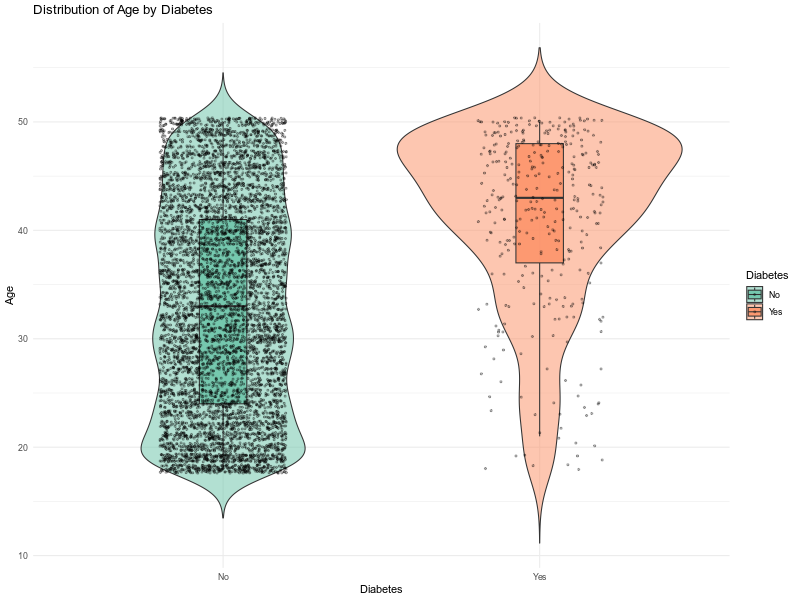

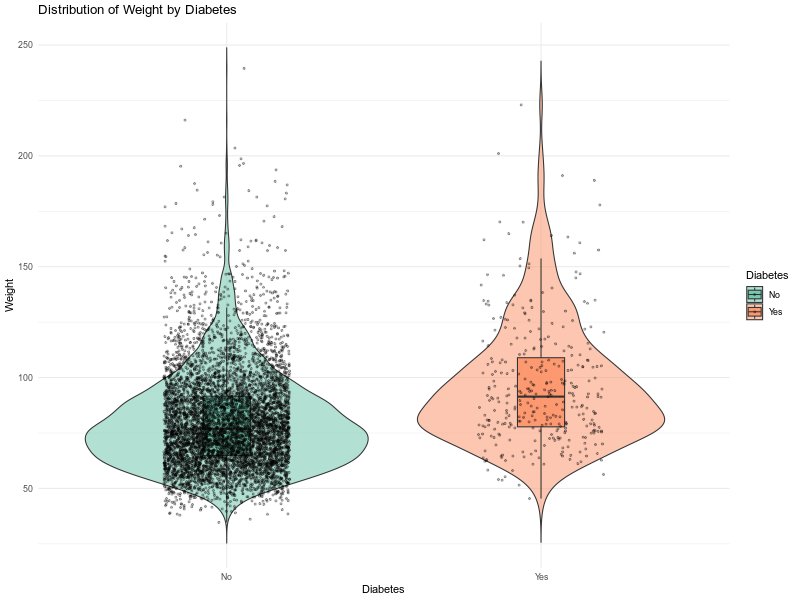

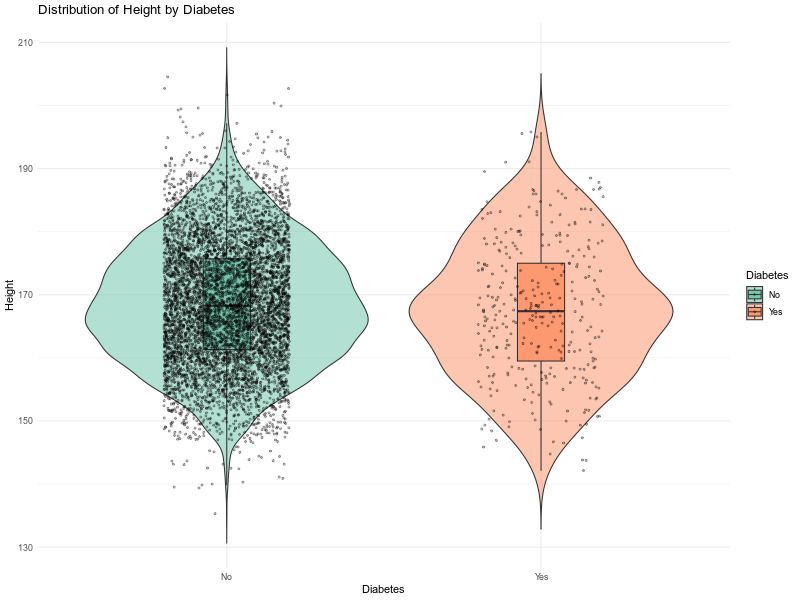

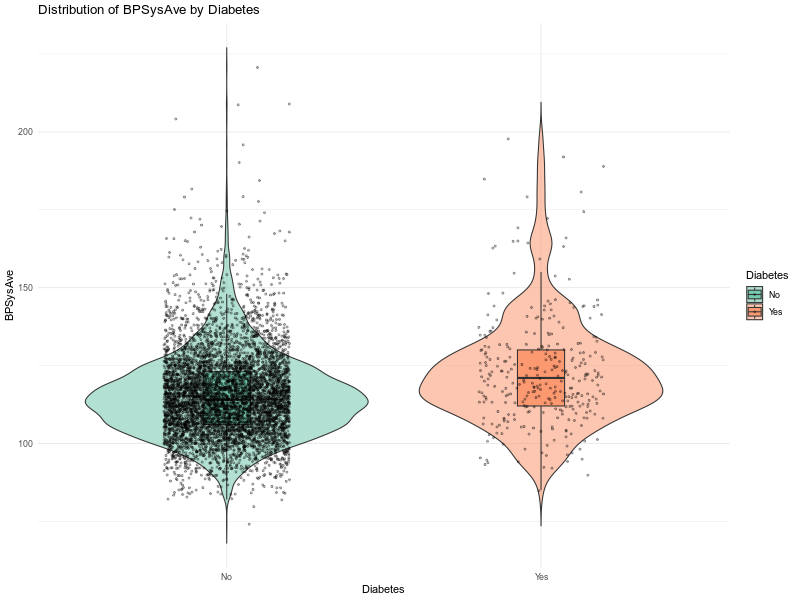

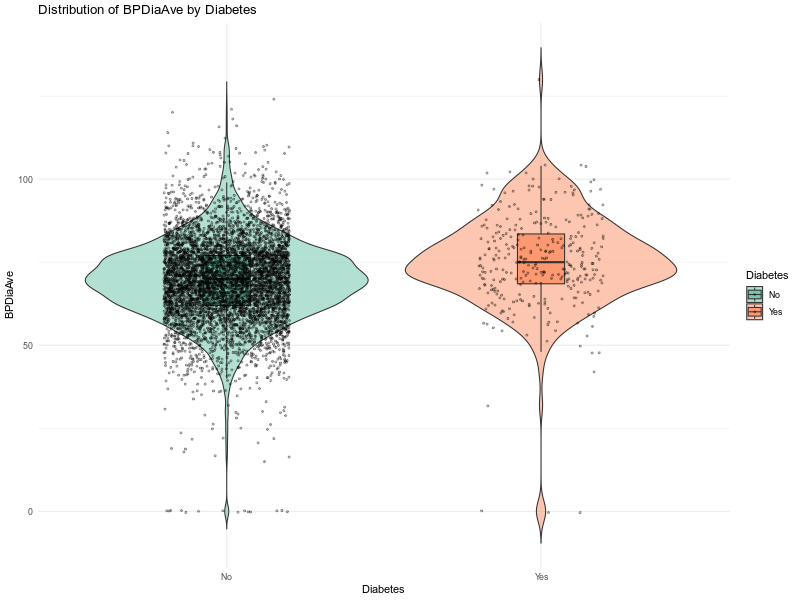

There were 24 warnings (use warnings() to see them)


In [26]:
for (v in num_vars) {
  p <- ggplot(df, aes(x = .data[[outcome]], y = .data[[v]], fill = .data[[outcome]])) +
    geom_violin(alpha = 0.5, trim = FALSE) +
    geom_boxplot(width = 0.15, alpha = 0.8, outlier.shape = NA) +
    geom_jitter(width = 0.2, alpha = 0.3, size = 0.8) +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal() +
    labs(title = paste("Distribution of", v, "by", outcome),
         x = outcome, y = v)
  print(p)
  ggsave(file.path(plots_dir, paste0("biv_", v, "_vs_", outcome, ".png")), p,
         width = 7, height = 5, dpi = 150)
}

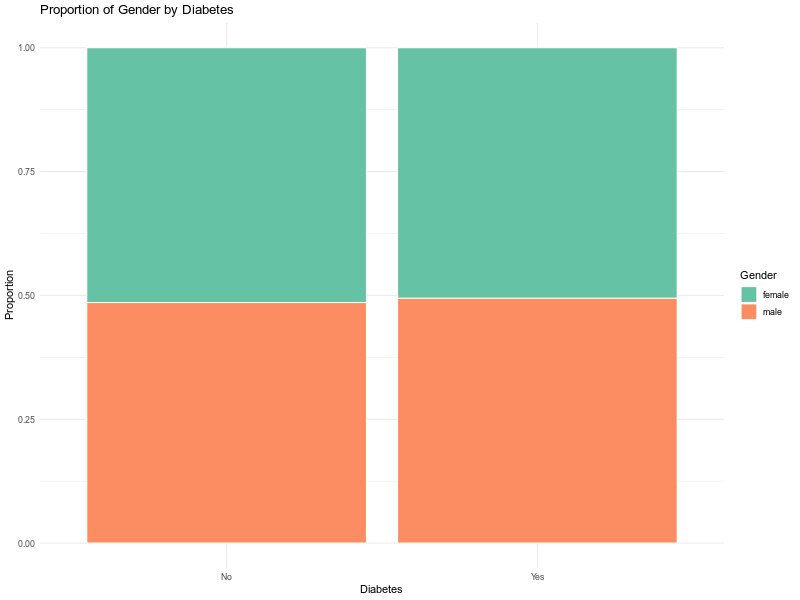

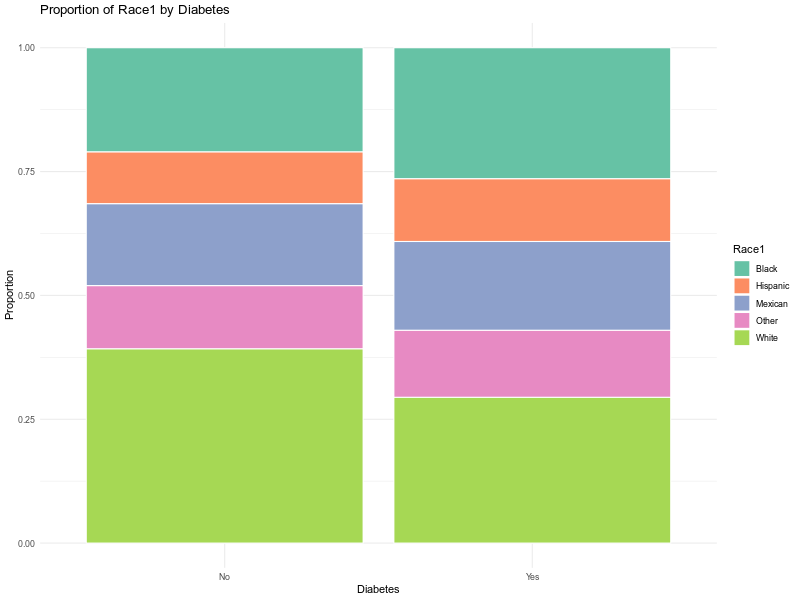

In [27]:
for (v in cat_vars) {
  p <- df %>%
    count(.data[[outcome]], .data[[v]]) %>%
    group_by(.data[[outcome]]) %>%
    mutate(prop = n / sum(n)) %>%
    ggplot(aes(x = .data[[outcome]], y = prop, fill = .data[[v]])) +
    geom_col(position = "fill", color = "white") +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal() +
    labs(title = paste("Proportion of", v, "by", outcome),
         x = outcome, y = "Proportion", fill = v)
  print(p)
  ggsave(file.path(plots_dir, paste0("biv_", v, "_vs_", outcome, ".png")), p,
         width = 7, height = 5, dpi = 150)
}

## 8. Findings

_Fill in once the cells above have been run — distribution shapes, missingness, top associations (low p-values), and caveats (small cells, heavy missingness, skew)._